# Quasi energy plots


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet


steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


In [3]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)


quasi_energies = []

for detuning in detunings:

    quasi_energies.append(ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m))


          

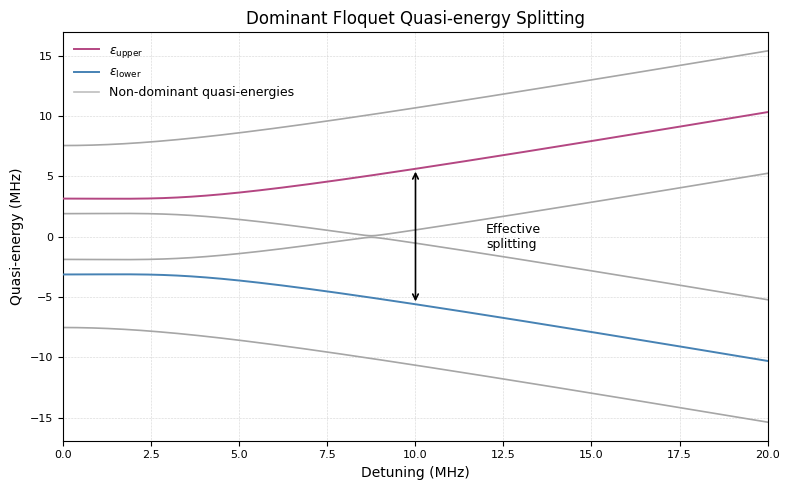

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure input is numpy array
quasi_energies = np.array(quasi_energies)
plt.figure(figsize=(8, 5))  # size suitable for publication

# Define dominant indices and LaTeX labels
dominant_indices = [1, 4]
dominant_labels = {
    4: r'$\epsilon_{\mathrm{upper}}$',
    1: r'$\epsilon_{\mathrm{lower}}$'
}

# Plot quasi-energies
# Dominants first (upper before lower), then non-dominants
for i in [4, 1] + [j for j in range(6) if j not in dominant_indices]:
    if i in dominant_indices:
        colour = plum if i == 4 else steel_blue
        lw = 1.4
        alpha = 1.0
        zorder = 3
        label = dominant_labels[i]
    else:
        colour = 'grey'
        lw = 1.2
        alpha = 0.7
        zorder = 1
        label = None
    plt.plot(detunings * 1000, quasi_energies[:, i] * 1000,
             color=colour, linewidth=lw, alpha=alpha, zorder=zorder, label=label)

# Add dummy entry to legend for non-dominant states
plt.plot([], [], color='grey', linewidth=1.2, alpha=0.5, label='Non-dominant quasi-energies')

# Add arrow showing energy splitting at central detuning
mid_idx = len(detunings) // 2
x_arrow = detunings[mid_idx] * 1000
y_lower = quasi_energies[mid_idx, 1] * 1000
y_upper = quasi_energies[mid_idx, 4] * 1000
plt.annotate('', xy=(x_arrow, y_upper), xytext=(x_arrow, y_lower),
             arrowprops=dict(arrowstyle='<->', color='black', linewidth=1.2))
plt.text(x_arrow + 2, (y_lower + y_upper)/2, 'Effective\nsplitting',
         va='center', ha='left', fontsize=9)

# Axis labels and ticks
plt.xlabel('Detuning (MHz)', fontsize=10)
plt.ylabel('Quasi-energy (MHz)', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Optional zero reference line (commented out by default)
# plt.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=1)

# Plot limits and style
plt.xlim(0, 4 * rabi_freq * 1000)
plt.grid(True, which='both', linestyle=':', linewidth=0.4)

# Title and legend
plt.title('Quasi-energies vs detuning from drive for CCD scheme ', fontsize=12)
plt.legend(fontsize=9, loc='upper left', frameon=False)

# Save and show
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/quasi_energies_vs_detuning.png', dpi=600)
plt.show()